In [204]:
import torch
torch.cuda.empty_cache()

In [205]:
import os 
import numpy as np

os.listdir('/kaggle/input/iq-othnccd/raw_dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset')

['IQ-OTH_NCCD lung cancer dataset.txt',
 'Normal cases',
 'Bengin cases',
 'Malignant cases']

**Cấu hình đường dẫn**

In [206]:
import torch

save_dir = "/kaggle/working/"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = '/kaggle/input/iq-othnccd/raw_dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'
batch = 32
ep = 400
pth = '/kaggle/working/fusion.pth'

**Augmentation, DataLoader**

In [207]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset,random_split
from PIL import Image
import random
import os

DATASET_PATH = data
BATCH_SIZE = batch
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=2),
    transforms.ColorJitter(brightness=0.3, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.3)),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

**Single Input**

In [208]:
# class SingleInputDataset(Dataset):
#     def __init__(self, dataset, indices, transform):
#         self.dataset = dataset
#         self.indices = indices
#         self.transform = transform

#     def __getitem__(self, idx):
#         image, label = self.dataset[self.indices[idx]]
#         image = self.transform(image)
#         return image, label

#     def __len__(self):
#         return len(self.indices)

# raw_dataset = datasets.ImageFolder(root=DATASET_PATH)
# all_indices = list(range(len(raw_dataset)))
# random.shuffle(all_indices)
# total_size = len(all_indices)
# test_size = int(0.1 * total_size)
# val_size = int(0.2 * total_size)
# train_size = total_size - test_size - val_size
# test_indices = all_indices[:test_size]
# val_indices = all_indices[test_size:test_size + val_size]
# train_indices = all_indices[test_size + val_size:]
# train_dataset = SingleInputDataset(raw_dataset, train_indices, train_transform)
# val_dataset = SingleInputDataset(raw_dataset, val_indices, val_test_transform)
# test_dataset = SingleInputDataset(raw_dataset, test_indices, val_test_transform)
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

**Fusion Input**

In [209]:
class DualInputDataset(Dataset):
    def __init__(self, dataset, indices, transform1, transform2):
        self.dataset = dataset
        self.indices = indices
        self.transform1 = transform1
        self.transform2 = transform2

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        input1 = self.transform1(image)
        input2 = self.transform2(image)
        return input1, input2, label

    def __len__(self):
        return len(self.indices)

raw_dataset = datasets.ImageFolder(root=DATASET_PATH)
total_size = len(raw_dataset)
test_size = int(0.1 * total_size)
train_val_size = total_size - test_size
indices = list(range(total_size))
random.shuffle(indices)
test_indices = indices[:test_size]
train_val_indices = indices[test_size:]
val_size = int(0.2 * len(train_val_indices))  
train_size = len(train_val_indices) - val_size
train_indices = train_val_indices[:train_size]
val_indices = train_val_indices[train_size:]
train_dataset = DualInputDataset(raw_dataset, train_indices, train_transform, train_transform)
val_dataset = DualInputDataset(raw_dataset, val_indices, val_test_transform, val_test_transform)
test_dataset = DualInputDataset(raw_dataset, test_indices, val_test_transform, val_test_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers = 4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers = 4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers = 4)

**Mô hình**

**MobileNet V1**

In [210]:
import torch
import torch.nn as nn

# Depthwise separable convolution block
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, 
                                   stride=stride, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, 
                                   stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x

# MobileNetV1 chính
class MobileNetV1(nn.Module):
    def __init__(self, num_classes=1000):
        super(MobileNetV1, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),  # 224x224 -> 112x112
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            DepthwiseSeparableConv(32, 64, stride=1),
            DepthwiseSeparableConv(64, 128, stride=2),
            DepthwiseSeparableConv(128, 128, stride=1),
            DepthwiseSeparableConv(128, 256, stride=2),
            DepthwiseSeparableConv(256, 256, stride=1),
            DepthwiseSeparableConv(256, 512, stride=2),

            # 5x depthwise conv with stride 1
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),

            DepthwiseSeparableConv(512, 1024, stride=2),
            DepthwiseSeparableConv(1024, 1024, stride=1),

            nn.AdaptiveAvgPool2d(1)
        )
        self.drop = nn.Dropout(0.8)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.model(x)
        x = x.view(-1, 1024)
        x = self.drop(x)
        x = self.fc(x)
        return x

**MobileNet V3 Small**

In [211]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HardSwish(nn.Module):
    def forward(self, x):
        return x * F.relu6(x + 3) / 6

class SqueezeExcite(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        reduced_channels = max(1, in_channels // reduction)
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Conv2d(in_channels, reduced_channels, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_channels, in_channels, 1),
            nn.Hardsigmoid(inplace=True)
        )

    def forward(self, x):
        scale = self.squeeze(x)
        scale = self.excitation(scale)
        return x * scale

class MobileBottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, use_se, activation):
        super().__init__()
        hidden_dim = int(in_channels * expand_ratio)
        self.use_res_connect = stride == 1 and in_channels == out_channels

        layers = []
        if expand_ratio != 1:
            layers.append(nn.Conv2d(in_channels, hidden_dim, 1, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(nn.ReLU(inplace=True) if activation == "RE" else HardSwish())
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride, kernel_size // 2, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True) if activation == "RE" else HardSwish()
        ])
        if use_se:
            layers.append(SqueezeExcite(hidden_dim))
        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV3Small(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1, bias=False),
            nn.BatchNorm2d(16),
            HardSwish()
        )
        self.blocks = nn.Sequential(
            MobileBottleneck(16, 16, 3, 2, 1, True, "RE"),
            MobileBottleneck(16, 24, 3, 2, 72//16, False, "RE"),
            MobileBottleneck(24, 24, 3, 1, 88//24, False, "RE"),
            MobileBottleneck(24, 40, 5, 2, 4, True, "HS"),
            MobileBottleneck(40, 40, 5, 1, 6, True, "HS"),
            MobileBottleneck(40, 40, 5, 1, 6, True, "HS"),
            MobileBottleneck(40, 48, 5, 1, 3, True, "HS"),
            MobileBottleneck(48, 48, 5, 1, 3, True, "HS"),
            MobileBottleneck(48, 96, 5, 2, 6, True, "HS"),
            MobileBottleneck(96, 96, 5, 1, 6, True, "HS"),
            MobileBottleneck(96, 96, 5, 1, 6, True, "HS"),
        )
        self.final = nn.Sequential(
            nn.Conv2d(96, 576, 1, bias=False),
            nn.BatchNorm2d(576),
            HardSwish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(576, 1280, 1),
            HardSwish()
        )
        self.drop = nn.Dropout(0.3)
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.final(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        x = self.classifier(x)
        return x

**MbileNetV3 Large**

In [212]:
class HardSwish(nn.Module):
    def forward(self, x):
        return x * F.relu6(x + 3) / 6

class SqueezeExcite(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        reduced_channels = max(1, in_channels // reduction)
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Conv2d(in_channels, reduced_channels, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_channels, in_channels, 1),
            nn.Hardsigmoid(inplace=True)
        )

    def forward(self, x):
        scale = self.squeeze(x)
        scale = self.excitation(scale)
        return x * scale

class MobileBottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, use_se, activation):
        super().__init__()
        hidden_dim = int(in_channels * expand_ratio)
        self.use_res_connect = stride == 1 and in_channels == out_channels

        layers = []
        if expand_ratio != 1:
            layers += [
                nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU(inplace=True) if activation == "RE" else HardSwish()
            ]
        layers += [
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride, kernel_size // 2, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True) if activation == "RE" else HardSwish()
        ]
        if use_se:
            layers.append(SqueezeExcite(hidden_dim))
        layers += [
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ]
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV3Large(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            HardSwish()
        )

        self.blocks = nn.Sequential(
            MobileBottleneck(16, 16, 3, 1, 1, False, "RE"),
            MobileBottleneck(16, 24, 3, 2, 4, False, "RE"),
            MobileBottleneck(24, 24, 3, 1, 3, False, "RE"),
            MobileBottleneck(24, 40, 5, 2, 3, True, "RE"),
            MobileBottleneck(40, 40, 5, 1, 3, True, "RE"),
            MobileBottleneck(40, 40, 5, 1, 3, True, "RE"),
            MobileBottleneck(40, 80, 3, 2, 6, False, "HS"),
            MobileBottleneck(80, 80, 3, 1, 2.5, False, "HS"),
            MobileBottleneck(80, 80, 3, 1, 2.3, False, "HS"),
            MobileBottleneck(80, 80, 3, 1, 2.3, False, "HS"),
            MobileBottleneck(80, 112, 3, 1, 6, True, "HS"),
            MobileBottleneck(112, 112, 3, 1, 6, True, "HS"),
            MobileBottleneck(112, 160, 5, 2, 6, True, "HS"),
            MobileBottleneck(160, 160, 5, 1, 6, True, "HS"),
            MobileBottleneck(160, 160, 5, 1, 6, True, "HS"),
        )

        self.final = nn.Sequential(
            nn.Conv2d(160, 960, 1, bias=False),
            nn.BatchNorm2d(960),
            HardSwish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(960, 1280, 1),
            HardSwish()
        )

        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.final(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

**EfficientNet B1**

In [213]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class SqueezeExcite(nn.Module):
    def __init__(self, in_channels, se_ratio=0.25):
        super().__init__()
        squeezed_channels = max(1, int(in_channels * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, squeezed_channels, kernel_size=1),
            Swish(),
            nn.Conv2d(squeezed_channels, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(x)
        return x * scale

class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio, kernel_size, stride):
        super().__init__()
        self.stride = stride
        self.use_residual = (in_channels == out_channels and stride == 1)
        hidden_dim = in_channels * expand_ratio

        layers = []
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                Swish(),
            ])

        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=kernel_size, stride=stride,
                      padding=kernel_size // 2, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            Swish(),
            SqueezeExcite(hidden_dim),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        ])

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        else:
            return self.block(x)

class EfficientNetB1(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            Swish(),
        )

        self.blocks = nn.Sequential(
            MBConvBlock(32, 16, expand_ratio=1, kernel_size=3, stride=1),

            MBConvBlock(16, 24, expand_ratio=6, kernel_size=3, stride=2),
            MBConvBlock(24, 24, expand_ratio=6, kernel_size=3, stride=1),

            MBConvBlock(24, 40, expand_ratio=6, kernel_size=5, stride=2),
            MBConvBlock(40, 40, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(40, 40, expand_ratio=6, kernel_size=5, stride=1),

            MBConvBlock(40, 80, expand_ratio=6, kernel_size=3, stride=2),
            MBConvBlock(80, 80, expand_ratio=6, kernel_size=3, stride=1),
            MBConvBlock(80, 80, expand_ratio=6, kernel_size=3, stride=1),
            MBConvBlock(80, 80, expand_ratio=6, kernel_size=3, stride=1),

            MBConvBlock(80, 112, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(112, 112, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(112, 112, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(112, 112, expand_ratio=6, kernel_size=5, stride=1),

            MBConvBlock(112, 192, expand_ratio=6, kernel_size=5, stride=2),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),

            MBConvBlock(192, 320, expand_ratio=6, kernel_size=3, stride=1),
            MBConvBlock(320, 320, expand_ratio=6, kernel_size=3, stride=1),
        )

        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, kernel_size=1, bias=False),
            nn.BatchNorm2d(1280),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(1280, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return x

**Mô hình kết hợp**

**Concat cơ bản nhất**

In [214]:
# class AdvancedFusionModel(nn.Module):
#     def __init__(self, num_classes=27):
#         super().__init__()
#         self.depth_model = EfficientNetB1(num_classes=64)
#         self.depth_model_v2 = MobileNetV3Large(num_classes=64)

#         self.dropout = nn.Dropout(p=0.5)
#         self.classifier = nn.Sequential(
#             nn.Linear(64 + 64, num_classes)  # 64 từ depth, 64 từ csi
#         )

#     def forward(self, depth_input, depth_input_v2):
#         depth_feat = self.depth_model(depth_input)              # (B, 64)
#         depth_feat_v2 = self.depth_model_v2(depth_input_v2)                    # (B, 64)

#         fused_feat = torch.cat([depth_feat, depth_feat_v2], dim=-1)  # (B, 128)

#         return self.classifier(fused_feat)

#     def print_model_size(self):
#         total_params = sum(p.numel() for p in self.parameters())
#         trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
#         print(f"Tổng tham số: {total_params / 1e6:.2f}M")
#         print(f"Tham số huấn luyện được: {trainable_params / 1e6:.2f}M")

**Multi Head Attention + Cross Attention**

In [215]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.to_qkv = nn.Linear(dim, dim * 3)
        self.out_proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, D = x.shape
        x = x.unsqueeze(1)  # (B, 1, D)
        qkv = self.to_qkv(x).reshape(B, 1, 3, self.heads, D // self.heads)
        q, k, v = qkv[:, :, 0], qkv[:, :, 1], qkv[:, :, 2]  # (B, 1, heads, D//heads)

        q = q.transpose(1, 2)  # (B, heads, 1, D//h)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        attn = (q @ k.transpose(-1, -2)) * self.scale  # (B, heads, 1, 1)
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, 1, D)  # (B, 1, D)
        return self.out_proj(out.squeeze(1))  # (B, D)

class CrossAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        self.out_proj = nn.Linear(dim, dim)

    def forward(self, query_input, kv_input):
        B, D = query_input.shape
        query = self.q_proj(query_input).view(B, self.heads, D // self.heads)
        key = self.k_proj(kv_input).view(B, self.heads, D // self.heads)
        value = self.v_proj(kv_input).view(B, self.heads, D // self.heads)

        attn_scores = (query * key).sum(-1, keepdim=True) * self.scale  # (B, heads, 1)
        attn_weights = attn_scores.softmax(dim=1)  # (B, heads, 1)
        attn_output = (attn_weights * value).view(B, D)

        return self.out_proj(attn_output)

class AdvancedFusionModel(nn.Module):
    def __init__(self, num_classes=27):
        super().__init__()
        self.depth_model = MobileNetV1(num_classes=64)
        self.depth_model_v2 = MobileNetV3Large(num_classes=64)

        self.self_attn_depth = MultiHeadSelfAttention(64)
        self.self_attn_depth_v2 = MultiHeadSelfAttention(64)

        self.cross_attn_depth2depthv2 = CrossAttention(64)
        self.cross_attn_depthv22depth = CrossAttention(64)

        self.dropout = nn.Dropout(p=0.5)
        self.classifier = nn.Sequential(
            nn.Linear(64 * 2, num_classes)
        )

    def forward(self, depth_input, depth_input_v2):
        depth_feat = self.depth_model(depth_input)   # (B, 64)
        depth_feat_v2 = self.depth_model_v2(depth_input_v2)         # (B, 64)

        # Self-Attention for both
        depth_attn = self.self_attn_depth(depth_feat)
        depth_attn_v2 = self.self_attn_depth_v2(depth_feat_v2)

        # Cross-Attention
        depth2depthv2 = self.cross_attn_depth2depthv2(depth_attn, depth_attn_v2)
        depthv22depth = self.cross_attn_depthv22depth(depth_attn_v2, depth_attn)

        fused_feat = torch.cat([depth2depthv2, depthv22depth], dim=-1)
        fused_feat = self.dropout(fused_feat)
        return self.classifier(fused_feat)

    def print_model_size(self):
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Tổng tham số: {total_params / 1e6:.2f}M")
        print(f"Tham số huấn luyện được: {trainable_params / 1e6:.2f}M")

**FILM thay cho cross-attention, ACmixAttention thay cho self-attention**

In [216]:
# class ACmixAttention(nn.Module):
#     def __init__(self, input_dim, heads=4):
#         super(ACmixAttention, self).__init__()
#         self.heads = heads
#         self.scale = (input_dim // heads) ** -0.5
#         self.to_qkv = nn.Linear(input_dim, input_dim * 3)
#         self.conv_proj = nn.Linear(input_dim, input_dim)
#         self.norm = nn.LayerNorm(input_dim)

#     def forward(self, x):
#         if x.dim() == 2:
#             x = x.unsqueeze(1)
#         elif x.dim() != 3:
#             raise ValueError(f"Expected (B, S, D) or (B, D), got {x.shape}")

#         B, S, D = x.shape
#         qkv = self.to_qkv(x).reshape(B, S, 3, self.heads, D // self.heads)
#         q, k, v = qkv[:, :, 0], qkv[:, :, 1], qkv[:, :, 2]

#         q = q.transpose(1, 2)
#         k = k.transpose(1, 2)
#         v = v.transpose(1, 2)

#         attn = torch.matmul(q, k.transpose(-1, -2)) * self.scale
#         attn = attn.softmax(dim=-1)
#         attn_out = torch.matmul(attn, v)
#         attn_out = attn_out.transpose(1, 2).contiguous().view(B, S, D)

#         conv_out = self.conv_proj(x)
#         out = self.norm(attn_out + conv_out + x)

#         if out.size(1) == 1:
#             out = out.squeeze(1)
#         return out

# class FiLM(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.gamma = nn.Linear(input_dim, input_dim)
#         self.beta = nn.Linear(input_dim, input_dim)

#     def forward(self, x1, x2): 
#         gamma = self.gamma(x1)
#         beta = self.beta(x1)
#         return gamma * x2 + beta

# class AdvancedFusionModel(nn.Module):
#     def __init__(self, num_classes=3):
#         super().__init__()
#         self.depth_model = MobileNetV1(num_classes=64)         # CV branch
#         self.depth_model_v2 = MobileNetV3Large(num_classes=64)  

#         self.film_fusion = FiLM(64)
#         self.attn_fusion = ACmixAttention(128)

#         self.dropout = nn.Dropout(p=0)
#         self.classifier = nn.Sequential(
#             nn.Linear(128, num_classes),
#         )

#     def forward(self, depth_input, depth_input_v2):
#         depth_feat = self.depth_model(depth_input)
#         depth_feat_v2 = self.depth_model_v2(depth_input_v2)

#         # FiLM fusion
#         fusion = self.film_fusion(depth_feat_v2, depth_feat)
#         concat = torch.cat([fusion, depth_feat_v2], dim=-1)

#         attention_out = self.attn_fusion(concat)
#         attention_out = self.dropout(attention_out)

#         return self.classifier(attention_out)

#     def print_model_size(self):
#         total_params = sum(p.numel() for p in self.parameters())
#         trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
#         print(f"Tổng tham số: {total_params / 1e6:.2f}M")
#         print(f"Tham số huấn luyện được: {trainable_params / 1e6:.2f}M")

**Huấn luyện mô hình**

In [217]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0, path=pth):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.best_loss = float('inf') 
        self.counter = 0  
        self.early_stop = False  

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)  
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [218]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            focal_loss *= alpha_t
        return focal_loss.mean()

In [219]:
import torch.nn as nn
import torch

class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1):
        super(LabelSmoothingLoss, self).__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.criterion = nn.KLDivLoss(reduction='batchmean')

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        true_dist = torch.zeros_like(pred)
        true_dist.fill_(self.smoothing / (self.cls - 1))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return self.criterion(pred, true_dist)

In [220]:
def print_model_parameters(model):
    total_params = 0
    print("\n===== SỐ LƯỢNG THAM SỐ MỖI MÔ HÌNH =====")
    for name, module in model.named_children():
        params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        total_params += params
        print(f"{name:<25}: {params:,}")
    print(f"{'Tổng số tham số':<25}: {total_params:,}\n")

In [221]:
# import torch
import torch.optim as optim
import time
from tqdm import tqdm
from sklearn.metrics import classification_report
import warnings
import random
import timm
warnings.filterwarnings("ignore")

model = AdvancedFusionModel(num_classes=3).to(device)
# model = SqueezeNet(num_classes=3).to(device)
# model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=3).to(device)

print_model_parameters(model)

# criterion = FocalLoss(gamma=2.0)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=6, factor=0.5, verbose=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
early_stopping = EarlyStopping(patience=15, delta=0.01, path=pth)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_acc_l, train_loss_l, val_acc_l, val_loss_l = [], [], [], []
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        model.train()
        t_loss = 0.
        t_correct, t_total = 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for depth_input, depth_input_v2, labels in loop:
            depth_input, depth_input_v2, labels = depth_input.to(device), depth_input_v2.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(depth_input, depth_input_v2) 

        # for depth_input, labels in loop:
        #     depth_input, labels = depth_input.to(device), labels.to(device)
        #     optimizer.zero_grad()
        #     outputs = model(depth_input) 
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

            _, train_predict = torch.max(outputs.data, 1)
            t_correct += (train_predict == labels).sum().item()
            t_total += labels.size(0)

        train_loss = t_loss / len(train_loader)
        train_acc = t_correct / t_total * 100
        train_loss_l.append(train_loss)
        train_acc_l.append(train_acc)

        model.eval()
        v_loss = 0.
        v_correct, v_total = 0, 0
        y_pred_class, y_true_class = [], []

        with torch.no_grad():
            for depth_input, depth_input_v2, labels in val_loader:
                depth_input, depth_input_v2, labels = depth_input.to(device), depth_input_v2.to(device), labels.to(device)
                outputs = model(depth_input, depth_input_v2)

            # for depth_input, labels in val_loader:
            #     depth_input, labels = depth_input.to(device), labels.to(device)
            #     outputs = model(depth_input)
                
                loss = criterion(outputs, labels)
                v_loss += loss.item()

                _, v_predict = torch.max(outputs.data, 1)
                v_correct += (v_predict == labels).sum().item()
                v_total += labels.size(0)
                y_pred_class.extend(v_predict.cpu().numpy())
                y_true_class.extend(labels.cpu().numpy())

        val_loss = v_loss / len(val_loader)
        val_acc = v_correct / v_total * 100
        val_loss_l.append(val_loss)
        val_acc_l.append(val_acc)
        epoch_time = time.time() - epoch_start_time

        print(f'{epoch+1}/{num_epochs}: t_acc: {train_acc:.4f}, t_loss: {train_loss:.4f}, v_acc: {val_acc:.4f}, v_loss: {val_loss:.4f}, time: {epoch_time:.2f}s')

        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    total_time = time.time() - total_start_time
    print(f"Tổng thời gian huấn luyện: {total_time/60:.2f} phút")

    from sklearn.metrics import classification_report
    print(classification_report(y_true_class, y_pred_class))

    model.load_state_dict(torch.load(pth))
    return train_acc_l, train_loss_l, val_acc_l, val_loss_l, y_pred_class, y_true_class

train_acc_l, train_loss_l, val_acc_l, val_loss_l, y_pred_class, y_true_class = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=400)
torch.save(model.state_dict(), pth)


===== SỐ LƯỢNG THAM SỐ MỖI MÔ HÌNH =====
depth_model              : 3,272,576
depth_model_v2           : 4,282,182
self_attn_depth          : 16,640
self_attn_depth_v2       : 16,640
cross_attn_depth2depthv2 : 16,640
cross_attn_depthv22depth : 16,640
dropout                  : 0
classifier               : 387
Tổng số tham số          : 7,621,705



Epoch 1/400: 100%|██████████| 26/26 [00:08<00:00,  2.92it/s]


1/400: t_acc: 45.3202, t_loss: 1.0859, v_acc: 50.7389, v_loss: 1.0732, time: 10.17s


Epoch 2/400: 100%|██████████| 26/26 [00:08<00:00,  3.09it/s]


2/400: t_acc: 50.7389, t_loss: 1.0237, v_acc: 50.7389, v_loss: 0.9579, time: 9.76s


...

59/400: t_acc: 98.1527, t_loss: 0.0807, v_acc: 95.5665, v_loss: 0.0952, time: 9.70s


Epoch 60/400: 100%|██████████| 26/26 [00:08<00:00,  2.95it/s]


60/400: t_acc: 96.1823, t_loss: 0.1120, v_acc: 96.0591, v_loss: 0.0819, time: 10.14s


Epoch 61/400: 100%|██████████| 26/26 [00:08<00:00,  3.13it/s]


61/400: t_acc: 96.5517, t_loss: 0.0864, v_acc: 96.5517, v_loss: 0.0943, time: 9.57s
Early stopping triggered
Tổng thời gian huấn luyện: 10.04 phút
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.99      0.99      0.99       103
           2       0.96      0.96      0.96        80

    accuracy                           0.97       203
   macro avg       0.93      0.93      0.93       203
weighted avg       0.97      0.97      0.97       203



              precision    recall  f1-score   support

           0     0.8500    0.8500    0.8500        20
           1     0.9903    0.9903    0.9903       103
           2     0.9625    0.9625    0.9625        80

    accuracy                         0.9655       203
   macro avg     0.9343    0.9343    0.9343       203
weighted avg     0.9655    0.9655    0.9655       203



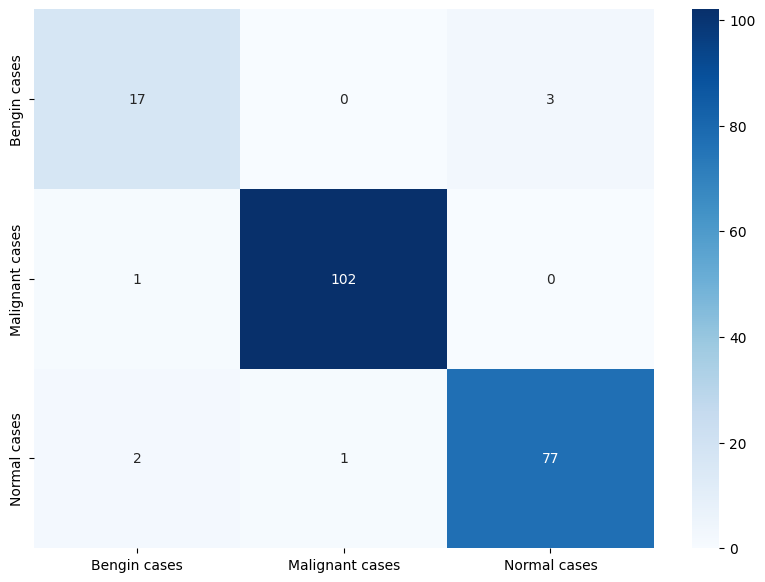

In [222]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os 

print(classification_report(y_true_class, y_pred_class, digits=4))

cm = confusion_matrix(y_pred_class, y_true_class)

plt.figure(figsize=(10,7))
sns.heatmap(cm, fmt='d', cmap='Blues', annot=True, xticklabels=raw_dataset.classes, yticklabels=raw_dataset.classes)
plt.show()

In [223]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, ax = plt.subplots(1, 2, figsize=(12,5))
# ax[0].plot(train_acc_l)
# ax[0].plot(val_acc_l)
# ax[0].legend(['Train', 'Val'])
# ax[0].set_title("Accuracy")

# ax[1].plot(train_loss_l)
# ax[1].plot(val_loss_l)
# ax[1].legend(['Train', 'Val'])
# ax[1].set_title("Loss")

# plt.show()

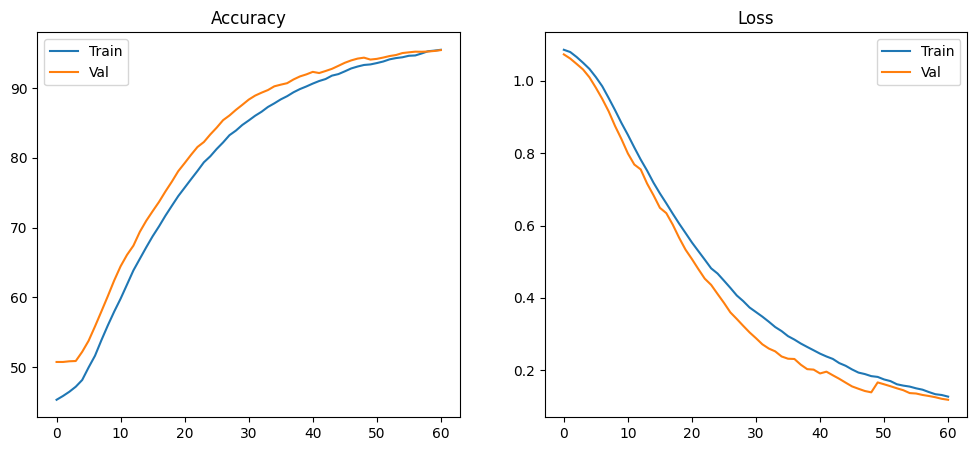

In [224]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, factor=0.9):
    smoothed = []
    last = points[0]
    for point in points:
        smoothed_val = last * factor + (1 - factor) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

train_acc_smoothed = smooth_curve(train_acc_l)
val_acc_smoothed = smooth_curve(val_acc_l)
train_loss_smoothed = smooth_curve(train_loss_l)
val_loss_smoothed = smooth_curve(val_loss_l)

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].plot(train_acc_smoothed)
ax[0].plot(val_acc_smoothed)
ax[0].legend(['Train', 'Val'])
ax[0].set_title("Accuracy")

ax[1].plot(train_loss_smoothed)
ax[1].plot(val_loss_smoothed)
ax[1].legend(['Train', 'Val'])
ax[1].set_title("Loss")

plt.show()

In [225]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn

# Thư mục chứa dữ liệu kiểm thử
test_dir = '/kaggle/input/lung-test/finaltest'

# Định nghĩa lớp TransformSubset
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        return self.transform(x), y

    def __len__(self):
        return len(self.subset)

# Tải raw dataset và gán transform
raw_test_dataset = datasets.ImageFolder(root=test_dir)
indices = list(range(len(raw_test_dataset)))
test_dataset = DualInputDataset(raw_test_dataset, indices, val_test_transform, val_test_transform)
# test_dataset = TransformSubset(raw_test_dataset, val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch, shuffle=False)

# Danh sách tên lớp
class_names = raw_test_dataset.classes
num_classes = len(class_names)

# Load mô hình
model = AdvancedFusionModel(num_classes=3).to(device)
# model = SqueezeNet(num_classes=3).to(device)
# model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=3).to(device)

model.load_state_dict(torch.load(pth, map_location=device))
model.eval()

# Biến đếm
class_correct = [0 for _ in range(num_classes)]
class_total = [0 for _ in range(num_classes)]

# Dự đoán
with torch.no_grad():
    # for inputs, labels in test_loader:
    #     inputs, labels = inputs.to(device), labels.to(device)
    #     outputs = model(inputs)
        
    for depth_input, depth_input_v2, labels in test_loader:
        depth_input, depth_input_v2, labels = depth_input.to(device), depth_input_v2.to(device), labels.to(device)
        outputs = model(depth_input, depth_input_v2)
        
        _, predicted = torch.max(outputs, 1)
        
        for i in range(labels.size(0)):
            label = labels[i].item()
            pred = predicted[i].item()
            if label == pred:
                class_correct[label] += 1
            class_total[label] += 1

# In kết quả từng lớp
for i in range(num_classes):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"Lớp {class_names[i]}: {class_correct[i]}/{class_total[i]} đúng ({acc:.2f}%)")

# Tổng thể
total_correct = sum(class_correct)
total_samples = sum(class_total)
total_acc = 100 * total_correct / total_samples
print(f"Tổng cộng: {total_correct}/{total_samples} ảnh đúng")
print(f"Độ chính xác tổng thể: {total_acc:.2f}%")

Lớp BenginCases: 43/50 đúng (86.00%)
Lớp MalignantCases: 187/200 đúng (93.50%)
Lớp normal: 96/100 đúng (96.00%)
Tổng cộng: 326/350 ảnh đúng
Độ chính xác tổng thể: 93.14%


75.14; 75.43; 77.14; 82.00